# GrapePPI Prediction

Use a trained GrapePPI model to predict protein–protein interactions. Input TSV: protein1_ID, protein2_ID (optional third column: label).

## 1. Dependencies and Model Definition

In [1]:
# Google Colab environment setup (run first if using Colab)
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Set to your Drive folder containing data/ and models/, or "/content" if you upload files
    COLAB_PROJECT_ROOT = "/content/drive/MyDrive/grape-ppi"
    import os
    os.chdir(COLAB_PROJECT_ROOT)
    print(f"Colab: cwd = {os.getcwd()}")
else:
    COLAB_PROJECT_ROOT = None
    print("Running locally.")

Mounted at /content/drive
Colab: cwd = /content/drive/MyDrive/grape-ppi


In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


class GrapePPI(nn.Module):
    def __init__(self, esm_dim=1280, hidden_dim=512, dropout=0.2):
        super(GrapePPI, self).__init__()
        self.sequence_encoder = nn.Sequential(
            nn.Linear(esm_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.interaction_predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1),
        )

    def combine_features(self, x1, x2):
        return torch.cat([x1, x2], dim=-1)

    def forward(self, x1, x2):
        x1 = self.sequence_encoder(x1)
        x2 = self.sequence_encoder(x2)
        x = self.combine_features(x1, x2)
        logits = self.interaction_predictor(x)
        return F.sigmoid(logits).squeeze()

In [3]:
class PooledDataset(Dataset):
    def __init__(self, names1, names2, labels, embedding_h5):
        self.names1 = names1
        self.names2 = names2
        self.labels = labels
        self.embed_data = {}
        names = set(names1).union(set(names2))
        with h5py.File(embedding_h5, "r") as h5fin:
            for name in names:
                self.embed_data[name] = torch.from_numpy(h5fin[name][:]).float()

    def __len__(self):
        return len(self.names1)

    def __getitem__(self, i):
        x1 = self.embed_data[self.names1[i]]
        x2 = self.embed_data[self.names2[i]]
        return x1, x2, torch.as_tensor(self.labels[i]).float()


def load_pooled_data(data_file, batch_size, embedding_h5, train=False):
    df = pd.read_csv(data_file, sep="\t", header=None)
    n_cols = df.shape[1]
    names1 = df[0].to_list()
    names2 = df[1].to_list()
    labels = df[2].to_list() if n_cols >= 3 else [0.0] * len(names1)
    dataset = PooledDataset(names1, names2, labels, embedding_h5)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False), names1, names2, labels

## 2. Configuration: Model Path and Data Path

In [4]:
# For Grape-1 dataset
data_dir = "./data/Grape-1"
model_path = os.path.join("models", "grape_1_model.pt")

# For Grape-10 dataset
# data_dir = "./data/Grape-10"
# model_path = os.path.join("models", "grape_10_model.pt")

embedding_h5 = os.path.join(data_dir, "esm2_t36_3B.h5")
# TSV to predict: at least two columns (protein1_ID, protein2_ID), optional third column for ground-truth label
predict_tsv = os.path.join(data_dir, "test.tsv")
output_csv = os.path.join("predictions", "test_prediction.csv")

batch_size = 128
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Model: {model_path}")
print(f"Input: {predict_tsv}")
print(f"Output: {output_csv}")

Device: cuda
Model: models/grape_1_model.pt
Input: ./data/Grape-1/test.tsv
Output: predictions/test_prediction.csv


## 3. Load Model and Predict

In [5]:
ckpt = torch.load(model_path, map_location=device, weights_only=False)
esm_dim = ckpt.get("esm_dim", 2560)
model = GrapePPI(esm_dim=esm_dim, hidden_dim=512, dropout=0.2)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()
print(f"Loaded epoch {ckpt.get('epoch', '?')}, val_loss={ckpt.get('val_loss', 0.):.4f}")
print(f"esm_dim={esm_dim}")

Loaded epoch 23, val_loss=0.2854
esm_dim=2560


In [6]:
loader, names1, names2, labels = load_pooled_data(predict_tsv, batch_size, embedding_h5)
y_pred_list = []
y_true_list = []
with torch.no_grad():
    for x1, x2, y in loader:
        x1, x2 = x1.to(device), x2.to(device)
        pred = model(x1, x2)
        y_pred_list.append(pred.cpu().numpy())
        y_true_list.append(y.numpy())

y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)
print(f"Predictions: {len(y_pred)}")

Predictions: 3300


## 4. Save Prediction Results

In [7]:
os.makedirs(os.path.dirname(output_csv) or '.', exist_ok=True)
out_df = pd.DataFrame({
    "protein1": names1,
    "protein2": names2,
    "y_pred": y_pred,
    "y_true": y_true,
})
out_df.to_csv(output_csv, index=False)
print(f"Saved to {output_csv}")
out_df.head(10)

Saved to predictions/test_prediction.csv


,protein1,protein2,y_pred,y_true
0,29760.D7TEE6,29760.D7U2J6,4.625895e-02,0.0
1,29760.F6HXZ8,29760.F6I624,3.407374e-06,0.0
2,29760.D7TAX7,29760.D7TRJ8,2.681623e-01,1.0
3,29760.D7TN95,29760.D7U2M3,1.487908e-11,0.0
4,29760.D7SIV1,29760.F6HH29,9.278409e-01,1.0
5,29760.F6HDK6,29760.F6HH30,7.918345e-03,0.0
6,29760.F6GY15,29760.F6H1E5,2.271821e-06,0.0
7,29760.P0CD56,29760.Q0ZJ16,9.993160e-01,1.0
8,29760.D7TAM3,29760.D7TLR8,1.389682e-01,1.0
9,29760.D7SJL6,29760.F6HLD5,6.057387e-03,0.0


## 5. Evaluation Metrics (requires ground-truth labels)

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Only evaluate when ground-truth labels are available (non-trivial)
has_labels = len(set(y_true)) > 1

if has_labels:
    threshold = 0.5
    y_bin = (y_pred >= threshold).astype(int)

    acc  = accuracy_score(y_true, y_bin)
    prec = precision_score(y_true, y_bin, zero_division=0)
    rec  = recall_score(y_true, y_bin, zero_division=0)
    f1   = f1_score(y_true, y_bin, zero_division=0)
    roc  = roc_auc_score(y_true, y_pred)
    pr   = average_precision_score(y_true, y_pred)

    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "PR AUC"],
        "Value":  [acc, prec, rec, f1, roc, pr],
    })
    metrics_df["Value"] = metrics_df["Value"].map(lambda x: f"{x*100:.2f}%")
    print(metrics_df.to_string(index=False))
else:
    print("No ground-truth labels found — skipping evaluation.")

   Metric  Value
 Accuracy 90.24%
Precision 89.74%
   Recall 90.62%
       F1 90.18%
  ROC AUC 95.86%
   PR AUC 95.52%


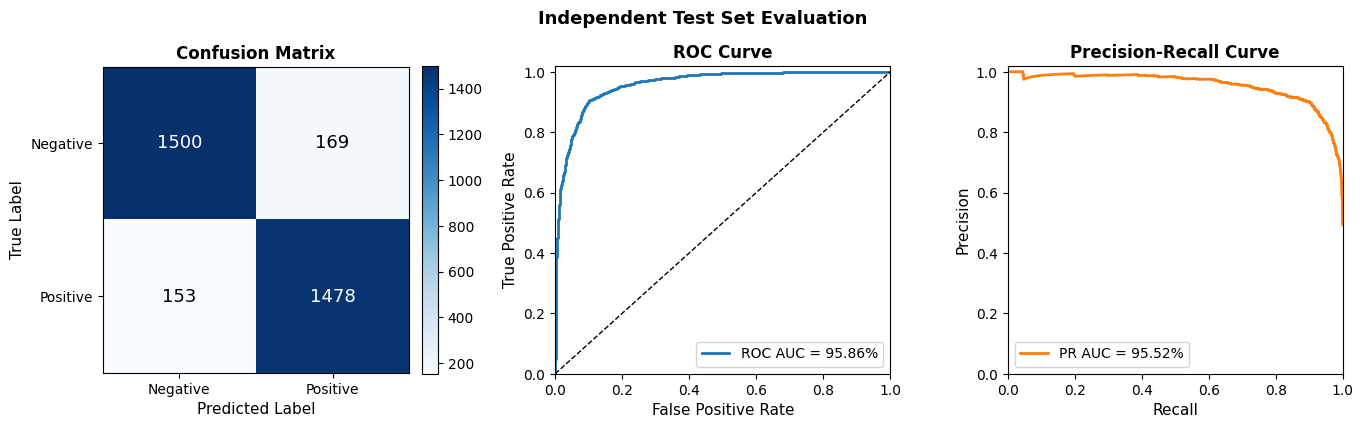

Figure saved to predictions/test_evaluation.png


In [9]:
if has_labels:
    fig = plt.figure(figsize=(16, 4))
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # --- Confusion Matrix ---
    ax0 = fig.add_subplot(gs[0])
    cm = confusion_matrix(y_true, y_bin)
    im = ax0.imshow(cm, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
    ax0.set_xticks([0, 1]); ax0.set_yticks([0, 1])
    ax0.set_xticklabels(["Negative", "Positive"], fontsize=10)
    ax0.set_yticklabels(["Negative", "Positive"], fontsize=10)
    ax0.set_xlabel("Predicted Label", fontsize=11)
    ax0.set_ylabel("True Label", fontsize=11)
    ax0.set_title("Confusion Matrix", fontsize=12, fontweight="bold")
    for i in range(2):
        for j in range(2):
            ax0.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)

    # --- ROC Curve ---
    ax1 = fig.add_subplot(gs[1])
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    ax1.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC AUC = {roc*100:.2f}%")
    ax1.plot([0, 1], [0, 1], "k--", lw=1)
    ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])
    ax1.set_xlabel("False Positive Rate", fontsize=11)
    ax1.set_ylabel("True Positive Rate", fontsize=11)
    ax1.set_title("ROC Curve", fontsize=12, fontweight="bold")
    ax1.legend(loc="lower right", fontsize=10)

    # --- Precision-Recall Curve ---
    ax2 = fig.add_subplot(gs[2])
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_pred)
    ax2.plot(rec_curve, prec_curve, color="#ff7f0e", lw=2, label=f"PR AUC = {pr*100:.2f}%")
    ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])
    ax2.set_xlabel("Recall", fontsize=11)
    ax2.set_ylabel("Precision", fontsize=11)
    ax2.set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
    ax2.legend(loc="lower left", fontsize=10)

    fig.suptitle("Independent Test Set Evaluation", fontsize=13, fontweight="bold", y=1.02)

    plot_path = os.path.join("predictions", "test_evaluation.png")
    os.makedirs("predictions", exist_ok=True)
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {plot_path}")